In [2]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import sys
sys.path.append('..')
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 1 / E_beta    # time
print("reduced mass (a.u.)", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass (a.u.) 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 2.677725627038548e-06


In [3]:
num_samples = 5000

scale = 1

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos / scale
print("mean spacing (E6)", mean_spacing)

# thermal properties
temp = 1 / scale       # in terms of E6
num_resonances = 400        # should be odd
print("T/d", temp / mean_spacing)

rrkm_c6 = 2 * np.pi / mean_spacing 
print("RRKM (tau_beta)", rrkm_c6)
print("RRKM (s)", rrkm_c6 * tau_beta * tau0 / scale)

mean spacing (E6) 0.06729858526586742
T/d 14.859153369263785
RRKM (tau_beta) 93.36281412688626
RRKM (s) 0.00024999999999999995


In [4]:
mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [17]:
ds = np.array([0.01, 0.05, 0.09])
Ts = 1 / np.array([1, 4, 7])
print(Ts)
ratio = []
for d in ds:
    for Tp in Ts:
        ratio.append(d / Tp)
print(np.sort(np.array(ratio)))

[1.         0.25       0.14285714]
[0.01 0.04 0.05 0.07 0.09 0.2  0.35 0.36 0.63]


In [8]:
from tqdm import tqdm
from scipy.signal import find_peaks
import pickle

mean_spacing_dict = {}
with open('mean_spacing_sqrt.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)
# mean_x = 1

couplings = [1]

# 0.08855077008666766, 0.1, 0.316, 1, 3.16, 10, 31.6, 100
# [274.16760284403034, 0.06729858526586742]
for mean_spacing in np.arange(0.1, 2.1, 0.1):
    temp = 1
    if mean_spacing.item() in mean_spacing_dict:
        print(mean_spacing)
        continue

    energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
    dE = energy_grid[1] - energy_grid[0]

    for mean_x in couplings:
        mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
        total_delay = []

        for i in tqdm(range(len(total_delay), 1000)):
            energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
            time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
            
            peaks, _ = find_peaks(time_delays.get(), height=10)

            new_energies = np.array([])
            peak_vals = energy_grid[peaks]

            insert = np.array([i * dE / 400 for i in range(400)])

            # if len(peak_vals) > 150:
            #     print("over")
            #     # continue

            if len(peak_vals) > 0:
                for energy in energy_grid:
                    near_peak = False

                    diff = np.abs(energy - peak_vals)
                    if np.min(diff) < 2 * dE:
                        near_peak = True

                    if near_peak:
                        new_energies = np.append(new_energies, energy + insert)
                    else:
                        new_energies = np.append(new_energies, energy)
            else:
                new_energies = energy_grid

            weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
            new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

            total_delay.append(np.sum(new_thermal_delay).item())

        mean_spacing_dict[mean_spacing.item()] = total_delay

        with open('mean_spacing_sqrt.pkl', 'wb') as f:
            pickle.dump(mean_spacing_dict, f)

0.1
0.2
0.30000000000000004
0.4
0.5
0.6000000000000001
0.7000000000000001
0.8
0.9
1.0
1.1
1.2000000000000002


100%|██████████| 1000/1000 [5:37:12<00:00, 20.23s/it] 


In [ ]:
from tqdm import tqdm
from scipy.signal import find_peaks
import pickle

mean_spacing_dict = {}
with open('mean_spacing_coupling_dense.pkl', 'rb') as f:
        mean_spacing_dict = pickle.load(f)
# mean_x = 1

couplings = np.power(10., np.concatenate(np.array([[i, -i] for i in range(3, 0, -1)])))
# couplings = np.power(10., np.concatenate(np.array([[i] for i in range(0, 10)]) / 10))
print(couplings)
# couplings = [1]
counter = 0
restart = True

# 0.08855077008666766, 0.1, 0.316, 1, 3.16, 10, 31.6, 100
# [274.16760284403034, 0.06729858526586742]
for mean_spacing in [0.06729858526586742]:
    if mean_spacing > 1:
        temp = 0.01
    else:
        temp = 1

    energy_grid = np.linspace(0, 10 * temp, 50000)[1:]
    dE = energy_grid[1] - energy_grid[0]

    for mean_x in couplings:

        if (mean_spacing, mean_x.item()) in mean_spacing_dict:
            print("Done")
            continue

        mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
        total_delay = []
        if restart:
            restart = False
            with open('temp.pkl', 'rb') as f:
                total_delay = pickle.load(f)

        for i in tqdm(range(len(total_delay), 1000)):
            energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
            time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
            
            peaks, _ = find_peaks(time_delays.get(), height=10)

            new_energies = np.array([])
            peak_vals = energy_grid[peaks]

            insert = np.array([i * dE / 400 for i in range(400)])

            # if len(peak_vals) > 150:
            #     print("over")
            #     # continue

            if len(peak_vals) > 0:
                for energy in energy_grid:
                    near_peak = False

                    diff = np.abs(energy - peak_vals)
                    if np.min(diff) < 2 * dE:
                        near_peak = True

                    if near_peak:
                        new_energies = np.append(new_energies, energy + insert)
                    else:
                        new_energies = np.append(new_energies, energy)
            else:
                new_energies = energy_grid

            weights = relative_MB_weights(temp, new_energies) * wigner_smith_matrix(new_energies, energy_GOE_mat, np.square(W_mat))
            new_thermal_delay = np.append(new_energies[1:] - new_energies[:-1], dE) * weights

            total_delay.append(np.sum(new_thermal_delay).item())

            with open('temp.pkl', 'wb') as f:
                pickle.dump(total_delay, f)

        mean_spacing_dict[(mean_spacing, mean_x.item())] = total_delay

        with open('mean_spacing_coupling_dense.pkl', 'wb') as f:
            pickle.dump(mean_spacing_dict, f)

[1.e+03 1.e-03 1.e+02 1.e-02 1.e+01 1.e-01]
Done
Done
Done


100%|██████████| 1000/1000 [2:27:06<00:00,  8.83s/it] 


In [7]:
import pickle
name = 'dense_fixed'
with open(f'mean_spacing_{name}.pkl', 'rb') as f:
    mean_spacing_dict = pickle.load(f)
print(len(mean_spacing_dict.keys()))

1


0.06729858526586742
92.7958373901977
7.134970654520684


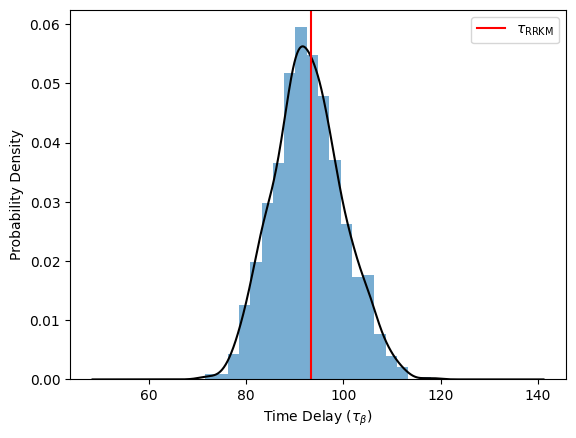

In [8]:
import pandas as pd
for mean_spacing in mean_spacing_dict.keys():
    print(mean_spacing)
    rrkm = 2 * np.pi / mean_spacing
    rrkm_c6 = 1
    normalized = np.array(mean_spacing_dict[mean_spacing]).get() / rrkm_c6

    fig, ax = plt.subplots()
    df = pd.DataFrame({"Mean Spacing": normalized})
    plot1 = df.plot(kind="hist", density=True, bins=20,ax=ax,alpha=0.6)
    plot2 = df.plot(kind="kde",ax=ax,color="black")
    vline = plt.axvline(rrkm, color="red", label=r"$\tau_{\text{RRKM}}$")
    print(np.mean(normalized) / rrkm_c6)
    # plt.xlim(-2, 2)
    plt.xlabel(r"Time Delay ($\tau_\beta)$")
    plt.ylabel("Probability Density")
    print(np.std(normalized))
    plt.legend([vline],[r"$\tau_{\text{RRKM}}$"])
    # plt.title(r"$k_bT=1\ E_\beta$")
    # plt.savefig("sparse_thermal_T=1.pdf")
    # plt.savefig(f"{name}_thermal.pdf", bbox_inches='tight')
    plt.show()

dict_keys([0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6000000000000001, 0.7000000000000001, 0.8, 0.9, 1.0, 1.1, 1.2000000000000002, 1.3, 1.4000000000000001, 1.5, 1.6, 1.7000000000000002, 1.8, 1.9000000000000001, 2.0])
[array(0.99660641), array(0.99370619), array(0.99924096), array(0.98328251), array(0.98259861), array(0.99348732), array(0.97674121), array(0.97669705), array(0.96416156), array(0.98102542), array(0.97133636), array(0.98160295), array(0.97833643), array(0.97651996), array(0.97941113), array(0.96865965), array(0.96789676), array(0.98205162), array(0.97291095), array(0.96316147)]


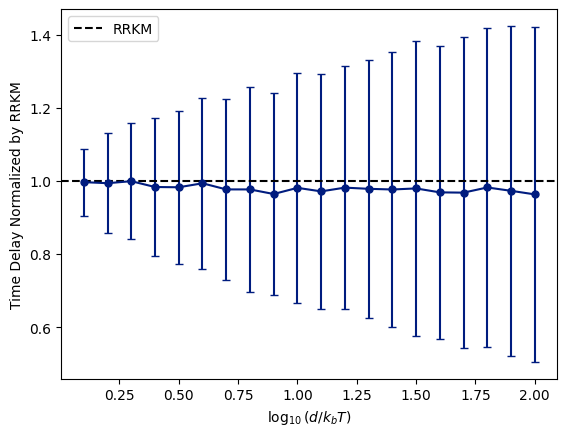

In [45]:
plt.style.use('seaborn-v0_8-dark-palette')
means = []
stds = []
mean_spacings = []
keys = list(mean_spacing_dict.keys())
for mean_spacing in keys:
    data = np.array(mean_spacing_dict[mean_spacing])
    rrkm = 2 * np.pi / mean_spacing 

    # plt.hist(data.get() / rrkm, bins=50)
    # # plt.xlim(0, 2)
    # plt.xlabel(r"Time Delay ($\tau_{RRKM}$)")
    # plt.ylabel("Counts")
    # plt.show()

    means.append(np.mean(data / rrkm).get())
    stds.append(np.std(data / rrkm).get())
    mean_spacings.append(mean_spacing)
print(mean_spacing_dict.keys())
plt.errorbar(np.array(mean_spacings).get(), means, yerr=stds, fmt='o-', markersize=5, capsize=3)
plt.axhline(1, color="black", label=r"RRKM", linestyle='--')
print(means)
# plt.ylim(-2, 2)
# plt.xlim(-3, 3)
plt.xlabel(r"$\log_{10}(d / k_bT)$")
plt.ylabel(r"$\langle Q \rangle / \tau_{\text{RRKM}}$")
plt.ylabel(r"Time Delay Normalized by RRKM")
plt.legend()
# plt.savefig("delay_distribution.pdf")
# plt.savefig("delay_distribution.png", bbox_inches='tight')

[0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8
 1.9 2. ]
[0.31072267 0.56193972] [[ 3.56063503e-06 -1.02009544e-05]
 [-1.02009544e-05  1.32520713e-04]]


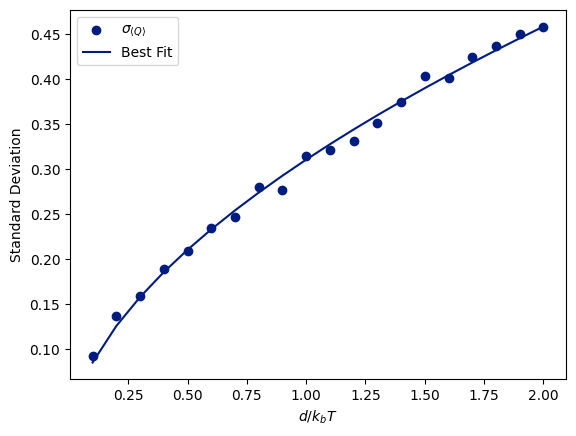

In [78]:
plt.scatter(np.array(mean_spacings).get(), np.array(stds).get(), label=r"$\sigma_{\langle Q \rangle}$")
print(np.array(mean_spacings).get())

import scipy as sc
import numpy as np_actual
x = np.array(mean_spacings).get()
y = np.array(stds).get()

def func(x, c, a):
    return c * np_actual.pow(x, a)

popt, pcov = sc.optimize.curve_fit(func, x, y)
print(popt, pcov)

points = np.arange(0.1, 2.1, 0.1)
num_res = 1 / np.array(points)

plt.plot(np.array(points).get(), func(x, popt[0], popt[1]), label=r"Best Fit")
# plt.plot(np.array(points).get(), res.slope * np.array(points).get() + res.intercept)
# plt.xlim(0, 2)
# plt.ylim(0, 1)
plt.xlabel(r"$d / k_bT$")
plt.ylabel(r"Standard Deviation")
plt.legend()
plt.savefig("delay_distribution_std.pdf", bbox_inches='tight')

0.06729858526586742 1000.0
90.37875299746709
7.48391960761054


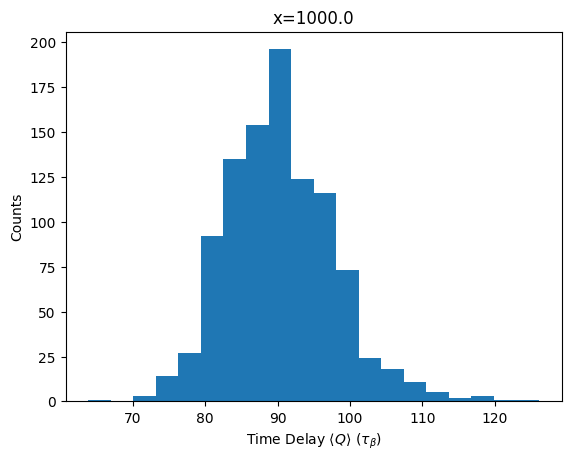

0.06729858526586742 0.001
90.47186907461263
8.495283114211551


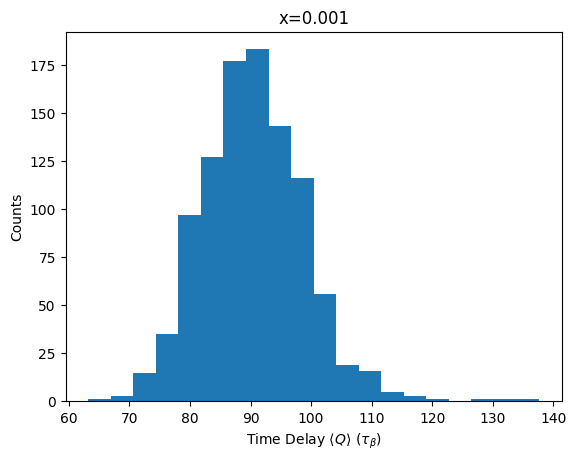

0.06729858526586742 100.0
91.61930728239336
7.311130454650454


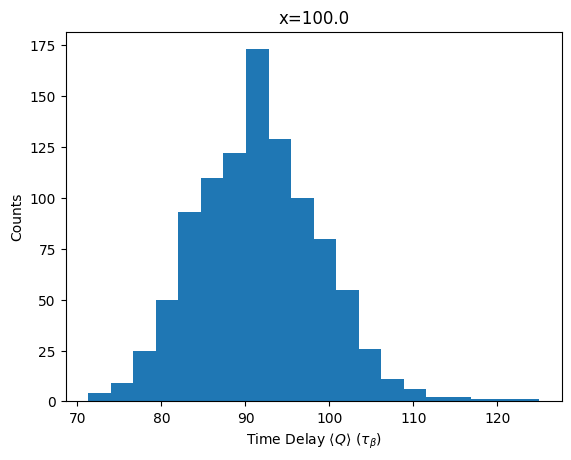

In [9]:
for key in mean_spacing_dict.keys():
    mean_spacing, x = key
    # if mean_spacing < 1:
    #     continue
    print(mean_spacing, x)
    rrkm = 2 * np.pi / mean_spacing
    rrkm_c6 = 1
    plt.hist(np.array(mean_spacing_dict[(mean_spacing, x)]).get() / rrkm_c6, bins=20)
    # plt.axvline(rrkm, color="red", label=r"$\tau_{\text{RRKM}}$")
    print(np.mean(np.array(mean_spacing_dict[(mean_spacing, x)]).get()) / rrkm_c6)
    # plt.xlim(-2, 2)
    plt.xlabel(r"Time Delay $\langle Q \rangle\ (\tau_\beta)$")
    plt.ylabel("Counts")
    print(np.std(np.array(mean_spacing_dict[(mean_spacing, x)]).get() / rrkm_c6))
    plt.title(r"x=" + str(x))
    # plt.legend()
    # plt.savefig("dense_thermal.pdf")
    plt.show()